In [1]:
import os

from keras.src.ops import convert_to_tensor
from tensorflow.python.ops.variables import trainable_variables

os.environ['TF_CPP_MIN_LOG_LEVEL'] ='3'
import matplotlib
matplotlib.rcParams['figure.figsize'] = [9, 6]
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.experimental import dtensor
tf.random.set_seed(22)

/home/fernando/PyCharmMiscProject/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
def configure_virtual_cpus(ncpu):
    phy_devices = tf.config.list_physical_devices('CPU')
    tf.config.set_logical_device_configuration(phy_devices[0], [tf.config.LogicalDeviceConfiguration()] * ncpu)


configure_virtual_cpus(8)
DEVICES = [f'CPU: {i}' for i in range(8)]
devices = tf.config.list_logical_devices('CPU')
device_names = [d.name for d in devices]
device_names

['/device:CPU:0',
 '/device:CPU:1',
 '/device:CPU:2',
 '/device:CPU:3',
 '/device:CPU:4',
 '/device:CPU:5',
 '/device:CPU:6',
 '/device:CPU:7']

In [3]:
train_data , test_data = tfds.load("mnist", split=['train[:5000]', 'test[:5000]'], as_supervised=True, batch_size=128)

In [4]:
def preprocess(x, y):
    x = tf.reshape(x, shape=[-1, 784])
    x = x / 255
    return x, y


train_data, test_data = train_data.map(preprocess), test_data.map(preprocess)

In [5]:
class DenseLayer(tf.Module):
    def __init__(self, in_dim, out_dim, weight_layout, activation=tf.identity):
        super().__init__()
        self.in_dim, self.out_dim = in_dim, out_dim
        self.activation = activation
        uniform_initializer = tf.function(tf.random.stateless_uniform)
        xavier_lim = tf.sqrt(6.) / tf.sqrt(tf.cast(self.in_dim + self.out_dim, tf.float32))
        self.w = dtensor.DVariable(dtensor.call_with_layout(uniform_initializer, weight_layout, shape=(self.in_dim, self.out_dim),
                                                            seed=(22, 23), minval=-xavier_lim, maxval=xavier_lim))
        bias_layout = weight_layout.delete([0])
        self.b = dtensor.DVariable(dtensor.call_with_layout(tf.zeros, bias_layout, shape=[out_dim]))

    def __call__(self, x):
        z = tf.add(tf.matmul(x, self.w), self.b)
        return self.activation(z)

In [6]:
class MLP(tf.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [7]:
mesh = dtensor.create_mesh([("batch", 8)], devices=DEVICES)
weight_layout = dtensor.Layout([dtensor.UNSHARDED, dtensor.UNSHARDED], mesh)

input_size = 784
hidden_layer_1_size = 700
hidden_layer_2_size = 500
output_size = 10

mlp_model = MLP([
    DenseLayer(in_dim=input_size, out_dim=hidden_layer_1_size, weight_layout=weight_layout, activation=tf.nn.relu),
    DenseLayer(in_dim=hidden_layer_1_size, out_dim=hidden_layer_2_size, weight_layout=weight_layout, activation=tf.nn.relu),
    DenseLayer(in_dim=hidden_layer_2_size, out_dim=output_size, weight_layout=weight_layout),
])

In [8]:
def cross_entropy_loss(y_pred, y):
    sparse_ce = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=y_pred)
    return tf.reduce_mean(sparse_ce)


def accuracy(y_pred, y):
    class_preds = tf.argmax(y_pred, axis=1)
    is_equal = tf.equal(y, class_preds)
    return tf.reduce_mean(tf.cast(is_equal, tf.float32))

In [9]:
class Adam(tf.Module):
    def __init__(self, model_vars, learning_rate=1e-3, beta_1=0.9, beta_2=0.999, ep=1e-7):
        super().__init__()
        self.model_vars = model_vars
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.learning_rate = learning_rate
        self.ep = ep
        self.t = 1
        self.v_dvar, self.s_dvar = [], []
        for var in model_vars:
            v = dtensor.DVariable(dtensor.call_with_layout(tf.zeros, var.layout, shape=var.shape))
            s = dtensor.DVariable(dtensor.call_with_layout(tf.zeros, var.layout, shape=var.shape))
            self.v_dvar.append(v)
            self.s_dvar.append(s)

    def apply_gradients(self, grads):
        for i, (d_var, var) in enumerate(zip(grads, self.model_vars)):
            self.v_dvar[i].assign(self.beta_1 * self.v_dvar[i] + (1 - self.beta_1) * d_var)
            self.s_dvar[i].assign(self.beta_2 * self.s_dvar[i] + (1 - self.beta_2) * tf.square(d_var))
            v_dvar_bc = self.v_dvar[i] / (1 - self.beta_1 ** self.t)
            s_dvar_bc = self.s_dvar[i] / (1 - self.beta_2 ** self.t)
            var.assign_sub(self.learning_rate * (v_dvar_bc / (tf.sqrt(s_dvar_bc) + self.ep)))
        self.t += 1
        return

In [16]:
def repack_local_tensor(x, layout):
    x = tf.convert_to_tensor(x)
    sharded_dims = []
    queue = [x]
    for axis, dim in enumerate(layout.sharding_specs):
        if dim == dtensor.UNSHARDED:
            continue
        num_splits = layout.shape[axis]
        queue = tf.nest.map_structure(lambda x: tf.split(x, num_splits, axis=axis), queue)
        sharded_dims.append(dim)
    components = []
    for locations in layout.mesh.local_device_locations():
        t = queue[0]
        for dim in sharded_dims:
            split_index = locations[dim]
            t = t[split_index]
        components.append(t)
    return dtensor.pack(components, layout)


def repack_batch(x, y, mesh):
    x = repack_local_tensor(x, layout=dtensor.Layout(['batch', dtensor.UNSHARDED], mesh))
    y = repack_local_tensor(y, layout=dtensor.Layout(['batch'], mesh))
    return x, y

In [17]:
@tf.function
def train_step(model, x_batch, y_batch, loss, metric, optimizer):
    with tf.GradientTape() as tape:
        y_pred = model(x_batch)
        batch_loss = loss(y_pred, y_batch)
    grads = tape.gradient(batch_loss, model.trainable_variables)
    optimizer.apply_gradients(grads)
    batch_acc = metric(y_pred, y_batch)
    return batch_loss, batch_acc


@tf.function
def test_step(model, x_batch, y_batch, loss, metric, optimizer):
    y_pred = model(x_batch)
    batch_loss = loss(y_pred, y_batch)
    batch_acc = metric(y_pred, y_batch)
    return batch_loss, batch_acc

In [19]:
epochs = 3
batch_size = 128
train_losses, test_losses = [], []
train_accs, test_accs = [], []
optimizer = Adam(mlp_model.trainable_variables)

for epoch in range(epochs):
    batch_losses_train, batch_accs_train = [], []
    batch_losses_test, batch_accs_test = [], []
    for x_batch, y_batch in train_data:
        x_batch, y_batch = repack_batch(x_batch, y_batch, mesh)
        batch_loss, batch_acc = train_step(mlp_model, x_batch, y_batch, cross_entropy_loss, accuracy, optimizer)
        batch_losses_train.append(batch_loss)
        batch_accs_train.append(batch_acc)
    for x_batch, y_batch in test_data:
        x_batch, y_batch = repack_batch(x_batch, y_batch, mesh)
        batch_loss, batch_acc = test_step(mlp_model, x_batch, y_batch, cross_entropy_loss, accuracy, optimizer)
        batch_losses_test.append(batch_loss)
        batch_accs_test.append(batch_acc)
    train_loss, train_acc = tf.reduce_mean(batch_losses_train), tf.reduce_mean(batch_accs_train)
    test_loss, test_acc = tf.reduce_mean(batch_losses_test), tf.reduce_mean(batch_accs_test)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    print(f'Epoch: {epoch}')
    print(f'Training loss: {train_loss.numpy():.3f}, Training accuracy: {train_acc.numpy():.3f}')
    print(f'Testing loss: {test_loss.numpy():.3f}, Test accuracy: {test_acc.numpy():.3f}')

Epoch: 0
Training loss: 1.212, Training accuracy: 0.612
Testing loss: 0.470, Test accuracy: 0.862
Epoch: 1
Training loss: 0.344, Training accuracy: 0.889
Testing loss: 0.313, Test accuracy: 0.901
Epoch: 2
Training loss: 0.213, Training accuracy: 0.936
Testing loss: 0.238, Test accuracy: 0.928


In [20]:
def plot_metrics(train_metric, test_metric, metric_type):
    plt.figure()
    plt.plot(range(len(train_metric)), train_metric, label=f'Training {metric_type}')
    plt.plot(range(len(test_metric)), test_metric, label=f'Testing {metric_type}')
    plt.xlabel("Epochs")
    plt.ylabel(metric_type)
    plt.legend()
    plt.title(f"{metric_type} vs Training epochs")

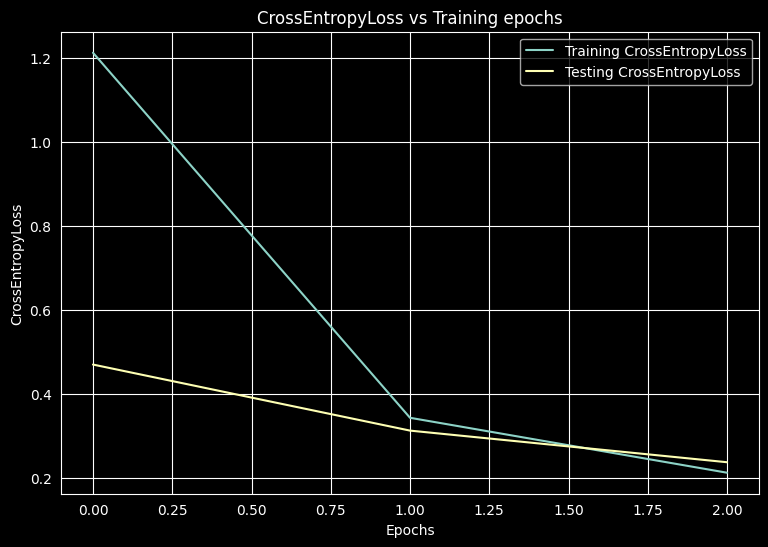

In [21]:
plot_metrics(train_losses, test_losses, 'CrossEntropyLoss')

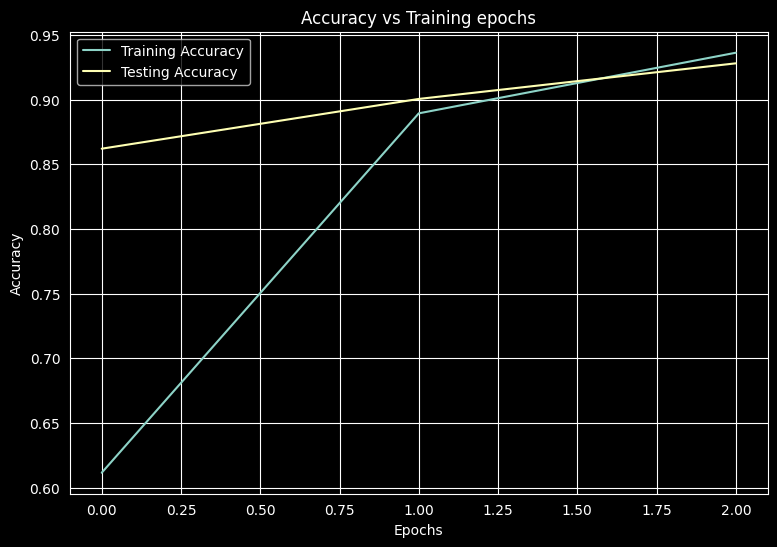

In [22]:
plot_metrics(train_accs, test_accs, 'Accuracy')